# Virtual patient diagnostics: what the current results actually support

This notebook is the report-facing version of the HIV synthetic-data story. It intentionally avoids the over-strong thesis that the current pipeline proves biologically faithful virtual patients.

**Defensible thesis:** synthetic HIV immune profiles are distinguishable in generator-specific ways, and the failure signatures can be localized to immune feature blocks and specific longitudinal antibody features. Clinical metadata is treated as a join audit and optional evaluation context, not as evidence that the generator preserves full clinical trajectories.

The notebook pulls the useful pieces from `synthetic_generator.ipynb` and `ablation_cvae.ipynb` into one tweakable workflow:

- RF real-vs-synthetic separability across generators.
- KLD vs RF separability, because marginal fidelity and classifier distinguishability do not tell the same story.
- Noise-response curves, because perturbation exposes generator-specific brittleness.
- RF-driven ablation and biological block localization, because distinguishability needs a biological address.
- Patient workbook audit, because clinical-context claims are only valid if the participant-level join is safe.


In [1]:
# Setup
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

CWD = Path.cwd().resolve()
if (CWD / 'data_synthesis').exists():
    REPO_ROOT = CWD
    DS_ROOT = REPO_ROOT / 'data_synthesis'
elif CWD.name == 'notebooks':
    DS_ROOT = CWD.parent
    REPO_ROOT = DS_ROOT.parent
else:
    DS_ROOT = CWD
    REPO_ROOT = DS_ROOT.parent

NOTEBOOK_DIR = DS_ROOT / 'notebooks'
OUTDIR = NOTEBOOK_DIR / 'virtual_patient_outputs'
OUTDIR.mkdir(parents=True, exist_ok=True)

for p in [DS_ROOT, DS_ROOT / 'src', DS_ROOT / 'rfhack' / 'core']:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from loaders import load_HIV
from models.bootstrap import sample_bootstrap
from models.iid_columnwise import sample_columnwise
from models.gmm import sample_gmm
from metrics import kld_per_feature, correlation_diff

METHOD_COLORS = {
    'bootstrap': '#4C78A8',
    'columnwise': '#F58518',
    'gmm': '#54A24B',
    'cvae': '#B279A2',
}
SEED = 42
N_REPEATS = 4
NOISE_REPEATS = 1
CVAE_EPOCHS = 80
RUN_CVAE = True

print('repo:', REPO_ROOT)
print('outputs:', OUTDIR)


repo: C:\Users\tonyt\Desktop\distinguishable_data
outputs: C:\Users\tonyt\Desktop\distinguishable_data\data_synthesis\notebooks\virtual_patient_outputs


## 1. Load the 63-feature HIV immune matrix

The analysis unit here is a participant-level immune-feature profile. The matrix contains longitudinal measurements encoded as separate columns, plus provided production/decay summaries. That means the rows are **not** visit rows.

In [2]:
hiv = load_HIV()
X = np.asarray(hiv['X'], dtype=np.float64)
y = np.asarray(hiv['y']).ravel().astype(int)
feature_names = list(hiv['feature_names'])
X_df = pd.DataFrame(X, columns=feature_names)

n0 = int((y == 0).sum())
n1 = int((y == 1).sum())

summary = pd.DataFrame({
    'n_participants': [len(y)],
    'n_features': [X.shape[1]],
    'class_0_without_HIV': [n0],
    'class_1_PLWH': [n1],
})
display(summary)



,n_participants,n_features,class_0_without_HIV,class_1_PLWH
0,91,63,23,68


In [3]:
# Biological feature blocks. These are intentionally name-based and auditable.
def cols_containing(*tokens):
    return [c for c in feature_names if all(t in c for t in tokens)]

# Assay/biology blocks.
feature_blocks = {
    'antibody_kinetics': [c for c in feature_names if ('Production' in c or 'Decay' in c)],
    'serum_igg_spike': cols_containing('blood_IgGspike'),
    'serum_igg_rbd': cols_containing('blood_IgGRBD'),
    'saliva_igg': [c for c in feature_names if 'Saliva_IgG' in c],
    'saliva_iga': [c for c in feature_names if 'Saliva_IgA' in c],
    't_cell_cytokine': [c for c in ['V8_IFNg', 'V9_IFNg', 'V8_IL2', 'V9_IL2', 'V8Dual', 'V9Dual', 'IFNG_production', 'Il2_production'] if c in feature_names],
    'cd4_neutrophil_context': [c for c in ['RATIO_CD4CD8', 'V8Neut', 'V9Neut'] if c in feature_names],
    'ace2_neutralization': [c for c in ['V7_ACE2', 'V8_ACE2', 'V8b_ACE2', 'V9_ACE2'] if c in feature_names],
}



# Higher-level biological compartment blocks for block ablation and synergy.
biology_blocks = {
    'cytokines': feature_blocks['t_cell_cytokine'],
    'saliva_IgA': feature_blocks['saliva_iga'],
    'saliva_IgG': feature_blocks['saliva_igg'],
    'serum_IgG': feature_blocks['serum_igg_spike'] + feature_blocks['serum_igg_rbd'],
    'neutralization_ACE2': feature_blocks['ace2_neutralization'],
    'CD4_CD8_neutrophils': feature_blocks['cd4_neutrophil_context'],
    'production_decay': feature_blocks['antibody_kinetics'],
}


# Orthogonal groupings worth testing because the matrix is longitudinally encoded.
visit_blocks = {
    'baseline_V1': [c for c in feature_names if c.startswith('V1_')],
    'post_D1_peak_V4_V4a': [c for c in feature_names if c.startswith(('V4_', 'V4a_'))],
    'post_D2_followup_V5_V6_V7': [c for c in feature_names if c.startswith(('V5_', 'V6_', 'V7_'))],
    'pre_or_around_D3_V8_V8a': [c for c in feature_names if c.startswith(('V8_', 'V8a_'))],
    'post_D3_peak_V8b_V9': [c for c in feature_names if c.startswith(('V8b_', 'V9_')) or c in ['V9Dual']],
    'late_followup_V10_V11': [c for c in feature_names if c.startswith(('V10_', 'V11_'))],
}

trajectory_blocks = {
    'serum_spike_trajectory_all_visits': [c for c in feature_names if 'blood_IgGspike' in c],
    'serum_rbd_trajectory_all_visits': [c for c in feature_names if 'blood_IgGRBD' in c],
    'saliva_spike_trajectory': [c for c in feature_names if 'Saliva' in c and 'spike' in c],
    'saliva_rbd_trajectory': [c for c in feature_names if 'Saliva' in c and 'RBD' in c],
    'neutralization_trajectory': [c for c in feature_names if 'ACE2' in c],
    'cellular_response_V8_V9': [c for c in feature_names if c in ['V8_IFNg', 'V9_IFNg', 'V8_IL2', 'V9_IL2', 'V8Dual', 'V9Dual', 'IFNG_production', 'Il2_production']],
}

all_test_blocks = {
    **{f'assay::{k}': v for k, v in feature_blocks.items()},
    **{f'visit::{k}': v for k, v in visit_blocks.items()},
    **{f'trajectory::{k}': v for k, v in trajectory_blocks.items()},
}

assigned = sorted({c for cols in feature_blocks.values() for c in cols})
unassigned = [c for c in feature_names if c not in assigned]
block_counts = pd.DataFrame({
    'block': list(all_test_blocks),
    'n_features': [len(v) for v in all_test_blocks.values()],
}).sort_values('n_features', ascending=False)

display(block_counts)
if unassigned:
    display(Markdown('**Unassigned features to inspect:** ' + ', '.join(unassigned)))


,block,n_features
12,visit::post_D3_peak_V8b_V9,17
11,visit::pre_or_around_D3_V8_V8a,11
1,assay::serum_igg_spike,10
2,assay::serum_igg_rbd,10
16,trajectory::saliva_spike_trajectory,10
3,assay::saliva_igg,10
14,trajectory::serum_spike_trajectory_all_visits,10
4,assay::saliva_iga,10
17,trajectory::saliva_rbd_trajectory,10
15,trajectory::serum_rbd_trajectory_all_visits,10


## 2. Generate synthetic immune profiles

The notebook includes the three lightweight generators used in the main pipeline and a CVAE branch. CVAE is important to the story, but it is computationally optional so the notebook remains tweakable while drafting.

In [4]:
def make_synthetics(seed=SEED, run_cvae=RUN_CVAE):
    methods = {
        'bootstrap': sample_bootstrap(X, y, n0, n1, seed=seed),
        'columnwise': sample_columnwise(X, y, n0, n1, seed=seed),
        'gmm': sample_gmm(X, y, n0, n1, seed=seed),
    }
    if run_cvae:
        try:
            from util.config import Config
            from models.cvae import train_cvae, sample_trained_cvae
            cfg = Config(seed=seed, epochs=CVAE_EPOCHS, hidden=128, z_dim=16, batch_size=64, x_transform='log1p')
            cvae_state = train_cvae(X, y, cfg=cfg, verbose=False)
            methods['cvae'] = sample_trained_cvae(cvae_state, n0, n1, seed=seed)
        except Exception as exc:
            print(f'CVAE skipped: {type(exc).__name__}: {exc}')
    return methods

synthetics = make_synthetics()
for name, (Xs, ys) in synthetics.items():
    print(f'{name:10s} X={Xs.shape} class0={(ys == 0).sum()} class1={(ys == 1).sum()}')


bootstrap  X=(91, 63) class0=23 class1=68
columnwise X=(91, 63) class0=23 class1=68
gmm        X=(91, 63) class0=23 class1=68
cvae       X=(91, 63) class0=23 class1=68


## 3. Distinguishability is real, but not one-dimensional

This section mirrors the useful story from `synthetic_generator.ipynb`: RF separability and KLD are different diagnostics. If a method has low KLD but high separability, marginal distributions look acceptable while multivariate structure still gives it away. If a method has higher KLD but lower separability, the reverse is true.

In [5]:
def as_kld_array(result):
    if isinstance(result, dict):
        return np.asarray(result.get('kld_per_feature', []), dtype=float)
    return np.asarray(result, dtype=float)

def corr_value(result, key):
    aliases = {
        'mean': ['mean_abs_diff', 'corr_mean_abs_diff'],
        'max': ['max_abs_diff', 'corr_max_abs_diff'],
    }
    for k in aliases[key]:
        if k in result:
            return float(result[k])
    raise KeyError((key, result.keys()))

def stratified_equal_indices(y_real, y_syn, seed):
    rng = np.random.default_rng(seed)
    idx = {}
    for label in [0, 1]:
        r = np.where(y_real == label)[0]
        s = np.where(y_syn == label)[0]
        n = min(len(r), len(s))
        idx[f'real_{label}'] = rng.choice(r, n, replace=False)
        idx[f'syn_{label}'] = rng.choice(s, n, replace=False)
    return np.r_[idx['real_0'], idx['real_1']], np.r_[idx['syn_0'], idx['syn_1']]


def one_rf_separability(X_real, y_real, X_syn, y_syn, seed=SEED, feature_idx=None):
    if feature_idx is None:
        feature_idx = np.arange(X_real.shape[1])
    real_idx, syn_idx = stratified_equal_indices(y_real, y_syn, seed)
    Xr = X_real[real_idx][:, feature_idx]
    Xs = X_syn[syn_idx][:, feature_idx]
    X_probe = np.vstack([Xr, Xs])
    s_probe = np.r_[np.zeros(len(Xr), dtype=int), np.ones(len(Xs), dtype=int)]
    X_train, X_test, y_train, y_test = train_test_split(
        X_probe, s_probe, test_size=0.30, stratify=s_probe, random_state=seed
    )
    rf = RandomForestClassifier(n_estimators=60, random_state=seed, n_jobs=-1)
    rf.fit(X_train, y_train)
    auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])
    return max(auc, 1 - auc)


def repeated_rf_separability(X_real, y_real, X_syn, y_syn, repeats=N_REPEATS, feature_idx=None):
    vals = [one_rf_separability(X_real, y_real, X_syn, y_syn, seed=SEED + r, feature_idx=feature_idx) for r in range(repeats)]
    return np.asarray(vals)


def fit_importance(X_real, y_real, X_syn, y_syn, seed=SEED):
    real_idx, syn_idx = stratified_equal_indices(y_real, y_syn, seed)
    Xr = X_real[real_idx]
    Xs = X_syn[syn_idx]
    X_probe = np.vstack([Xr, Xs])
    s_probe = np.r_[np.zeros(len(Xr), dtype=int), np.ones(len(Xs), dtype=int)]
    rf = RandomForestClassifier(n_estimators=60, random_state=seed, n_jobs=-1)
    rf.fit(X_probe, s_probe)
    return pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)

metric_rows = []
auc_distributions = {}
importance_by_method = {}
for method, (Xs, ys) in synthetics.items():
    sep_vals = repeated_rf_separability(X, y, Xs, ys)
    auc_distributions[method] = sep_vals
    kld = as_kld_array(kld_per_feature(X, Xs))
    corr = correlation_diff(X, Xs)
    importance_by_method[method] = fit_importance(X, y, Xs, ys)
    metric_rows.append({
        'method': method,
        'rf_sep_mean': sep_vals.mean(),
        'rf_sep_sd': sep_vals.std(ddof=1),
        'kld_mean': float(np.mean(kld)),
        'kld_max': float(np.max(kld)),
        'corr_mean_abs_diff': corr_value(corr, 'mean'),
        'corr_max_abs_diff': corr_value(corr, 'max'),
    })

metrics_df = pd.DataFrame(metric_rows).sort_values('rf_sep_mean', ascending=False)
display(metrics_df)

importance_df = pd.concat(importance_by_method, names=['method', 'feature']).reset_index(name='importance')


,method,rf_sep_mean,rf_sep_sd,kld_mean,kld_max,corr_mean_abs_diff,corr_max_abs_diff
2,gmm,1.000000,0.000000,1.109526,2.613460,0.095254,0.902218
3,cvae,0.993386,0.007713,5.981872,17.067326,0.251427,0.911697
1,columnwise,0.872851,0.038308,0.622542,1.670815,0.294860,1.029464
0,bootstrap,0.693618,0.062210,0.693525,1.912165,0.063260,0.337657


## 4. Noise response curves: perturbation as a failure-signature probe

This is the strongest currently defensible ?method? idea. The noise sweep does not prove biological realism. It tests how much feature-scaled perturbation is needed before synthetic profiles become trivially separable from real profiles, and whether methods fail in different ways.

In [6]:
def add_feature_scaled_noise(X_syn, X_ref, sigma, seed):
    rng = np.random.default_rng(seed)
    scale = np.nanstd(X_ref, axis=0)
    scale[scale == 0] = 1.0
    return X_syn + rng.normal(0, sigma * scale, size=X_syn.shape)

sigmas = [0.0, 0.025, 0.05, 0.10, 0.20, 0.30, 0.50, 1.0, 1.5, 2.0]
noise_rows = []
for method, (Xs, ys) in synthetics.items():
    for sigma in sigmas:
        vals = []
        for r in range(NOISE_REPEATS):
            Xn = add_feature_scaled_noise(Xs, X, sigma=sigma, seed=SEED + 1000 * r)
            vals.append(one_rf_separability(X, y, Xn, ys, seed=SEED + r))
        noise_rows.append({
            'method': method,
            'sigma': sigma,
            'rf_sep_mean': float(np.mean(vals)),
            'rf_sep_sd': float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0,
        })
noise_df = pd.DataFrame(noise_rows)
display(noise_df.head())


,method,sigma,rf_sep_mean,rf_sep_sd
0,bootstrap,0.000,0.757937,0.0
1,bootstrap,0.025,0.715608,0.0
2,bootstrap,0.050,0.737434,0.0
3,bootstrap,0.100,0.878307,0.0
4,bootstrap,0.200,0.973545,0.0


## 5. Biological block and RF-driven ablation localize the signal

This is where the paper becomes immunology-specific rather than generic tabular ML. The question is not only ?can RF separate real from synthetic?? but ?which immune measurement families give the classifier leverage??

### Additional groupings to test

The 63 columns should be tested through three complementary grouping schemes: assay blocks, visit-window blocks, and trajectory blocks. The visit-window blocks are especially important because `patient.xlsx` records dose and visit timing (`Days between D1 and D2`, `Days between D2 and V8`, `Days between D3 and V9`, and `Days after D1`). If synthetic profiles pass static assay-block checks but fail visit-window or trajectory checks, that directly supports the stronger immune-dynamics thesis.


In [7]:
from itertools import combinations

BLOCK_REPEATS = 2
SYNERGY_REPEATS = 2


def feature_indices(cols):
    return np.asarray([feature_names.index(c) for c in cols if c in feature_names], dtype=int)


def repeated_hiv_auc(X_data, y_data, feature_idx, repeats=BLOCK_REPEATS):
    """Repeated real-cohort HIV-status AUC for a selected feature set."""
    if len(feature_idx) == 0:
        return np.repeat(0.5, repeats)
    vals = []
    for r in range(repeats):
        X_sub = X_data[:, feature_idx]
        X_train, X_test, y_train, y_test = train_test_split(
            X_sub, y_data, test_size=0.30, stratify=y_data, random_state=SEED + r
        )
        rf = RandomForestClassifier(n_estimators=60, random_state=SEED + r, n_jobs=-1)
        rf.fit(X_train, y_train)
        vals.append(roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]))
    return np.asarray(vals)


def repeated_tstr_hiv_auc(X_real, y_real, X_syn, y_syn, feature_idx, repeats=BLOCK_REPEATS):
    """Train on synthetic, test on real HIV-status AUC for a selected feature set."""
    if len(feature_idx) == 0:
        return np.repeat(0.5, repeats)
    vals = []
    for r in range(repeats):
        rf = RandomForestClassifier(n_estimators=60, random_state=SEED + r, n_jobs=-1)
        rf.fit(X_syn[:, feature_idx], y_syn)
        vals.append(roc_auc_score(y_real, rf.predict_proba(X_real[:, feature_idx])[:, 1]))
    return np.asarray(vals)


def summarize_vals(vals):
    return float(np.mean(vals)), float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0


block_sets = {
    'biology': biology_blocks,
    'assay_granular': feature_blocks,
    'visit_window': visit_blocks,
    'trajectory': trajectory_blocks,
}

# 1. Real-cohort HIV classification by block: which biology contains signal?
real_block_rows = []
for scheme, blocks in block_sets.items():
    for block, cols in blocks.items():
        idx = feature_indices(cols)
        vals = repeated_hiv_auc(X, y, idx)
        mean, sd = summarize_vals(vals)
        real_block_rows.append({
            'scheme': scheme,
            'block': block,
            'n_features': len(idx),
            'real_HIV_auc_mean': mean,
            'real_HIV_auc_sd': sd,
        })
real_block_auc = pd.DataFrame(real_block_rows).sort_values(['scheme', 'real_HIV_auc_mean'], ascending=[True, False])
display(Markdown('### Real-cohort HIV classification by biological/visit/trajectory block'))
display(real_block_auc)

# 2. Train-on-synthetic test-on-real by block: does each generator preserve that signal?
tstr_block_rows = []
for method, (Xs, ys) in synthetics.items():
    for scheme, blocks in block_sets.items():
        for block, cols in blocks.items():
            idx = feature_indices(cols)
            vals = repeated_tstr_hiv_auc(X, y, Xs, ys, idx)
            mean, sd = summarize_vals(vals)
            real_mean = real_block_auc.query('scheme == @scheme and block == @block')['real_HIV_auc_mean'].iloc[0]
            tstr_block_rows.append({
                'method': method,
                'scheme': scheme,
                'block': block,
                'n_features': len(idx),
                'real_HIV_auc_mean': real_mean,
                'tstr_HIV_auc_mean': mean,
                'tstr_HIV_auc_sd': sd,
                'tstr_minus_real_auc': mean - real_mean,
            })
tstr_block_auc = pd.DataFrame(tstr_block_rows).sort_values(['scheme', 'method', 'tstr_minus_real_auc'])
display(Markdown('### Synthetic preservation of block-level HIV signal: TSTR AUC minus real-cohort AUC'))
display(tstr_block_auc)

# 3. Real-vs-synthetic block-only distinguishability: where do generators give themselves away?
block_rows = []
for method, (Xs, ys) in synthetics.items():
    for scheme, blocks in block_sets.items():
        for block, cols in blocks.items():
            idx = feature_indices(cols)
            if len(idx) == 0:
                continue
            vals = repeated_rf_separability(X, y, Xs, ys, repeats=BLOCK_REPEATS, feature_idx=idx)
            mean, sd = summarize_vals(vals)
            block_rows.append({
                'method': method,
                'scheme': scheme,
                'block': block,
                'n_features': len(idx),
                'real_vs_synthetic_sep_mean': mean,
                'real_vs_synthetic_sep_sd': sd,
            })
block_df = pd.DataFrame(block_rows).sort_values(['scheme', 'method', 'real_vs_synthetic_sep_mean'], ascending=[True, True, False])
display(Markdown('### Block-only real-vs-synthetic distinguishability'))
display(block_df)

# 4. Block-drop distinguishability: which biological blocks are necessary for the discriminator?
block_drop_rows = []
all_idx = set(range(X.shape[1]))
for method, (Xs, ys) in synthetics.items():
    for block, cols in biology_blocks.items():
        drop_idx = set(feature_indices(cols))
        keep_idx = np.asarray(sorted(all_idx - drop_idx), dtype=int)
        vals = repeated_rf_separability(X, y, Xs, ys, repeats=BLOCK_REPEATS, feature_idx=keep_idx)
        mean, sd = summarize_vals(vals)
        full_mean = metrics_df.loc[metrics_df['method'] == method, 'rf_sep_mean'].iloc[0]
        block_drop_rows.append({
            'method': method,
            'dropped_block': block,
            'dropped_n_features': len(drop_idx),
            'remaining_features': len(keep_idx),
            'full_sep_mean': full_mean,
            'drop_block_sep_mean': mean,
            'drop_block_sep_sd': sd,
            'sep_change_after_drop': mean - full_mean,
        })
block_drop_df = pd.DataFrame(block_drop_rows).sort_values(['method', 'sep_change_after_drop'])
display(Markdown('### Block-drop real-vs-synthetic distinguishability'))
display(block_drop_df)

# 5. Cross-block synergy for HIV-status classification.
# Synergy asks whether A+B exceeds the better individual block.
def block_pair_rows_for_real(blocks):
    rows = []
    singles = {}
    for block, cols in blocks.items():
        idx = feature_indices(cols)
        vals = repeated_hiv_auc(X, y, idx, repeats=SYNERGY_REPEATS)
        singles[block] = summarize_vals(vals)[0]
    for a, b in combinations(blocks.keys(), 2):
        pair_cols = list(dict.fromkeys(blocks[a] + blocks[b]))
        idx = feature_indices(pair_cols)
        vals = repeated_hiv_auc(X, y, idx, repeats=SYNERGY_REPEATS)
        pair_mean, pair_sd = summarize_vals(vals)
        rows.append({
            'block_A': a,
            'block_B': b,
            'n_features': len(idx),
            'real_pair_HIV_auc_mean': pair_mean,
            'real_pair_HIV_auc_sd': pair_sd,
            'real_A_auc': singles[a],
            'real_B_auc': singles[b],
            'real_synergy_over_best_single': pair_mean - max(singles[a], singles[b]),
        })
    return rows, singles

real_synergy_rows, real_single_auc = block_pair_rows_for_real(biology_blocks)
real_synergy_df = pd.DataFrame(real_synergy_rows).sort_values('real_synergy_over_best_single', ascending=False)
display(Markdown('### Cross-block synergy in real HIV-status classification'))
display(real_synergy_df)

# 6. Does each synthetic generator preserve pairwise synergy?
synthetic_synergy_rows = []
for method, (Xs, ys) in synthetics.items():
    synthetic_single = {}
    for block, cols in biology_blocks.items():
        idx = feature_indices(cols)
        synthetic_single[block] = summarize_vals(repeated_tstr_hiv_auc(X, y, Xs, ys, idx, repeats=SYNERGY_REPEATS))[0]
    for a, b in combinations(biology_blocks.keys(), 2):
        pair_cols = list(dict.fromkeys(biology_blocks[a] + biology_blocks[b]))
        idx = feature_indices(pair_cols)
        pair_mean, pair_sd = summarize_vals(repeated_tstr_hiv_auc(X, y, Xs, ys, idx, repeats=SYNERGY_REPEATS))
        real_row = real_synergy_df.query('block_A == @a and block_B == @b').iloc[0]
        syn_synergy = pair_mean - max(synthetic_single[a], synthetic_single[b])
        synthetic_synergy_rows.append({
            'method': method,
            'block_A': a,
            'block_B': b,
            'tstr_pair_HIV_auc_mean': pair_mean,
            'tstr_pair_HIV_auc_sd': pair_sd,
            'tstr_synergy_over_best_single': syn_synergy,
            'real_synergy_over_best_single': real_row['real_synergy_over_best_single'],
            'synergy_preservation_gap': syn_synergy - real_row['real_synergy_over_best_single'],
        })
synthetic_synergy_df = pd.DataFrame(synthetic_synergy_rows).sort_values(['method', 'synergy_preservation_gap'])
display(Markdown('### Synthetic preservation of cross-block HIV-classification synergy'))
display(synthetic_synergy_df)

# Primary block for top-feature display and heatmap panels.
feature_to_blocks = {}
for block, cols in biology_blocks.items():
    for c in cols:
        feature_to_blocks.setdefault(c, []).append(block)

def primary_block(feature):
    return feature_to_blocks.get(feature, ['unassigned'])[0]

block_importance = importance_df.assign(block=lambda d: d['feature'].map(primary_block))
block_importance = block_importance.groupby(['method', 'block'], as_index=False)['importance'].sum()
display(Markdown('### RF real-vs-synthetic feature importance aggregated to biological blocks'))
display(block_importance.sort_values(['method', 'importance'], ascending=[True, False]))


### Real-cohort HIV classification by biological/visit/trajectory block

,scheme,block,n_features,real_HIV_auc_mean,real_HIV_auc_sd
11,assay_granular,saliva_iga,10,0.982993,0.004810
12,assay_granular,t_cell_cytokine,8,0.979592,0.019241
13,assay_granular,cd4_neutrophil_context,3,0.935374,0.052913
10,assay_granular,saliva_igg,10,0.877551,0.115446
8,assay_granular,serum_igg_spike,10,0.816327,0.144308
9,assay_granular,serum_igg_rbd,10,0.801020,0.016836
7,assay_granular,antibody_kinetics,8,0.778912,0.091395
14,assay_granular,ace2_neutralization,4,0.773810,0.064938
1,biology,saliva_IgA,10,0.982993,0.004810
0,biology,cytokines,8,0.979592,0.019241


### Synthetic preservation of block-level HIV signal: TSTR AUC minus real-cohort AUC

,method,scheme,block,n_features,real_HIV_auc_mean,tstr_HIV_auc_mean,tstr_HIV_auc_sd,tstr_minus_real_auc
13,bootstrap,assay_granular,cd4_neutrophil_context,3,0.935374,0.933824,0.013563,-0.001551
11,bootstrap,assay_granular,saliva_iga,10,0.982993,0.991049,0.002261,0.008055
12,bootstrap,assay_granular,t_cell_cytokine,8,0.979592,0.997762,0.000452,0.018170
10,bootstrap,assay_granular,saliva_igg,10,0.877551,0.961637,0.003165,0.084086
8,bootstrap,assay_granular,serum_igg_spike,10,0.816327,0.916240,0.008590,0.099914
...,...,...,...,...,...,...,...,...
73,gmm,visit_window,post_D3_peak_V8b_V9,17,0.979592,0.991848,0.001130,0.012256
74,gmm,visit_window,late_followup_V10_V11,4,0.596939,0.613971,0.017406,0.017032
70,gmm,visit_window,post_D1_peak_V4_V4a,8,0.858844,0.887308,0.004747,0.028465
71,gmm,visit_window,post_D2_followup_V5_V6_V7,7,0.867347,0.898018,0.001808,0.030671


### Block-only real-vs-synthetic distinguishability

...

,block_A,block_B,n_features,real_pair_HIV_auc_mean,real_pair_HIV_auc_sd,real_A_auc,real_B_auc,real_synergy_over_best_single
12,saliva_IgG,neutralization_ACE2,14,0.914966,1.010153e-01,0.877551,0.773810,0.037415
13,saliva_IgG,CD4_CD8_neutrophils,13,0.959184,5.772300e-02,0.877551,0.935374,0.023810
15,serum_IgG,neutralization_ACE2,24,0.872449,4.569738e-02,0.848639,0.773810,0.023810
18,neutralization_ACE2,CD4_CD8_neutrophils,7,0.955782,2.405125e-02,0.773810,0.935374,0.020408
3,cytokines,neutralization_ACE2,12,0.993197,1.110223e-16,0.979592,0.773810,0.013605
11,saliva_IgG,serum_IgG,30,0.891156,1.010153e-01,0.877551,0.848639,0.013605
19,neutralization_ACE2,production_decay,12,0.789116,5.291275e-02,0.773810,0.778912,0.010204
0,cytokines,saliva_IgA,18,0.993197,9.620500e-03,0.979592,0.982993,0.010204
4,cytokines,CD4_CD8_neutrophils,11,0.986395,9.620500e-03,0.979592,0.935374,0.006803
14,saliva_IgG,production_decay,18,0.882653,1.467126e-01,0.877551,0.778912,0.005102


### Synthetic preservation of cross-block HIV-classification synergy

,method,block_A,block_B,tstr_pair_HIV_auc_mean,tstr_pair_HIV_auc_sd,tstr_synergy_over_best_single,real_synergy_over_best_single,synergy_preservation_gap
12,bootstrap,saliva_IgG,neutralization_ACE2,0.968990,0.005877,0.007353,0.037415,-0.030062
13,bootstrap,saliva_IgG,CD4_CD8_neutrophils,0.967231,0.003843,0.005595,0.023810,-0.018215
14,bootstrap,saliva_IgG,production_decay,0.951407,0.004521,-0.010230,0.005102,-0.015332
11,bootstrap,saliva_IgG,serum_IgG,0.962276,0.008138,0.000639,0.013605,-0.012966
3,bootstrap,cytokines,neutralization_ACE2,0.998561,0.000226,0.000799,0.013605,-0.012806
...,...,...,...,...,...,...,...,...
44,gmm,cytokines,serum_IgG,0.988491,0.000452,0.001598,-0.010204,0.011803
51,gmm,saliva_IgA,CD4_CD8_neutrophils,0.991049,0.000904,0.002398,-0.015306,0.017704
60,gmm,neutralization_ACE2,CD4_CD8_neutrophils,0.924073,0.011529,0.097986,0.020408,0.077578
62,gmm,CD4_CD8_neutrophils,production_decay,0.913683,0.015824,0.087596,-0.017007,0.104603


### RF real-vs-synthetic feature importance aggregated to biological blocks

,method,block,importance
6,bootstrap,serum_IgG,0.303678
5,bootstrap,saliva_IgG,0.164975
4,bootstrap,saliva_IgA,0.155890
3,bootstrap,production_decay,0.141589
1,bootstrap,cytokines,0.123823
2,bootstrap,neutralization_ACE2,0.058674
0,bootstrap,CD4_CD8_neutrophils,0.051372
13,columnwise,serum_IgG,0.338544
12,columnwise,saliva_IgG,0.190171
11,columnwise,saliva_IgA,0.179524


In [8]:
# Reverse ablation: drop the RF-ranked features and ask how quickly separability falls.
k_grid = list(range(0, X.shape[1] + 1))
ablation_rows = []
for method, (Xs, ys) in synthetics.items():
    ranked = importance_by_method[method].index.tolist()
    for k in k_grid:
        drop = set(ranked[:k])
        keep_cols = [c for c in feature_names if c not in drop]
        idx = feature_indices(keep_cols)
        if len(idx) == 0:
            continue
        vals = repeated_rf_separability(X, y, Xs, ys, repeats=1, feature_idx=idx)
        ablation_rows.append({
            'method': method,
            'dropped_top_k': k,
            'remaining_features': len(idx),
            'rf_sep_mean': vals.mean(),
            'rf_sep_sd': vals.std(ddof=1),
        })
ablation_df = pd.DataFrame(ablation_rows)
display(ablation_df.head())


,method,dropped_top_k,remaining_features,rf_sep_mean,rf_sep_sd
0,bootstrap,0,63,0.757937,NaN
1,bootstrap,1,62,0.767196,NaN
2,bootstrap,2,61,0.784392,NaN
3,bootstrap,3,60,0.772487,NaN
4,bootstrap,4,59,0.779101,NaN


## 6. One-page story figure

This is the plot to start from for the report. It avoids overclaiming by showing the actual diagnostic chain:

1. Methods differ in RF separability.
2. KLD and separability do not collapse to the same ranking.
3. Noise response curves expose perturbation sensitivity.
4. Biological blocks localize where distinguishability lives.

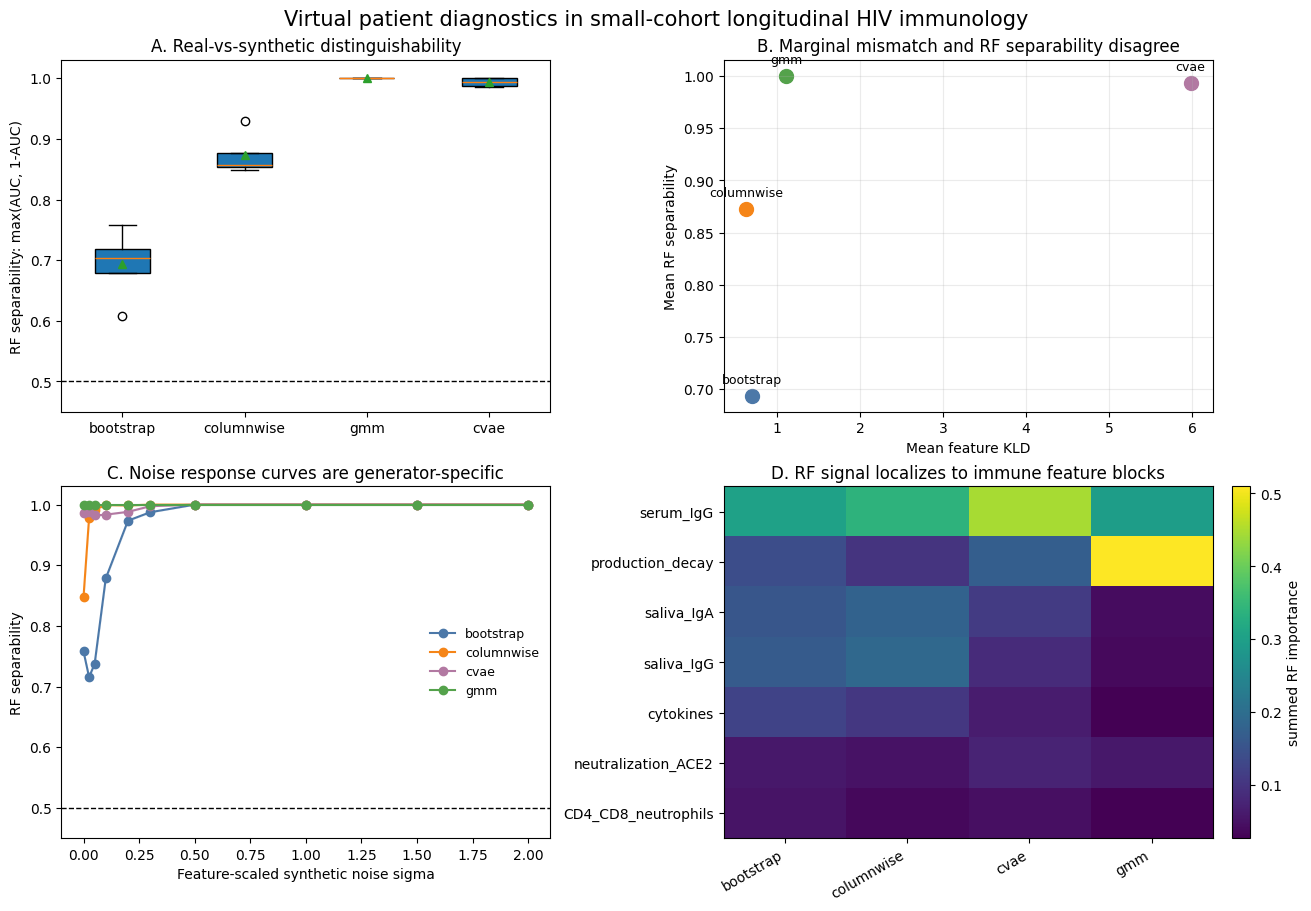

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)

# Panel A: separability distribution.
methods = list(synthetics.keys())
box_data = [auc_distributions[m] for m in methods]
axes[0, 0].boxplot(box_data, labels=methods, showmeans=True, patch_artist=True)
for patch, m in zip(axes[0, 0].artists, methods):
    patch.set_facecolor(METHOD_COLORS.get(m, 'gray'))
axes[0, 0].axhline(0.5, color='black', linestyle='--', linewidth=1)
axes[0, 0].set_ylabel('RF separability: max(AUC, 1-AUC)')
axes[0, 0].set_title('A. Real-vs-synthetic distinguishability')
axes[0, 0].set_ylim(0.45, 1.03)

# Panel B: KLD vs RF separability.
for _, row in metrics_df.iterrows():
    axes[0, 1].scatter(row['kld_mean'], row['rf_sep_mean'], s=100, color=METHOD_COLORS.get(row['method'], 'gray'))
    axes[0, 1].text(row['kld_mean'], row['rf_sep_mean'] + 0.012, row['method'], ha='center', fontsize=9)
axes[0, 1].set_xlabel('Mean feature KLD')
axes[0, 1].set_ylabel('Mean RF separability')
axes[0, 1].set_title('B. Marginal mismatch and RF separability disagree')
axes[0, 1].grid(alpha=0.25)

# Panel C: noise response.
for method, sub in noise_df.groupby('method'):
    sub = sub.sort_values('sigma')
    axes[1, 0].plot(sub['sigma'], sub['rf_sep_mean'], marker='o', label=method, color=METHOD_COLORS.get(method, None))
    axes[1, 0].fill_between(sub['sigma'], sub['rf_sep_mean'] - sub['rf_sep_sd'], sub['rf_sep_mean'] + sub['rf_sep_sd'], alpha=0.12, color=METHOD_COLORS.get(method, None))
axes[1, 0].axhline(0.5, color='black', linestyle='--', linewidth=1)
axes[1, 0].set_xlabel('Feature-scaled synthetic noise sigma')
axes[1, 0].set_ylabel('RF separability')
axes[1, 0].set_title('C. Noise response curves are generator-specific')
axes[1, 0].legend(frameon=False, fontsize=9)
axes[1, 0].set_ylim(0.45, 1.03)

# Panel D: block importance heatmap-like table.
pivot = block_importance.pivot(index='block', columns='method', values='importance').fillna(0.0)
pivot = pivot.reindex(pivot.mean(axis=1).sort_values(ascending=False).index)
im = axes[1, 1].imshow(pivot.values, aspect='auto', cmap='viridis')
axes[1, 1].set_xticks(np.arange(len(pivot.columns)))
axes[1, 1].set_xticklabels(pivot.columns, rotation=30, ha='right')
axes[1, 1].set_yticks(np.arange(len(pivot.index)))
axes[1, 1].set_yticklabels(pivot.index)
axes[1, 1].set_title('D. RF signal localizes to immune feature blocks')
fig.colorbar(im, ax=axes[1, 1], fraction=0.046, pad=0.04, label='summed RF importance')

fig.suptitle('Virtual patient diagnostics in small-cohort longitudinal HIV immunology', fontsize=15)
plt.show()


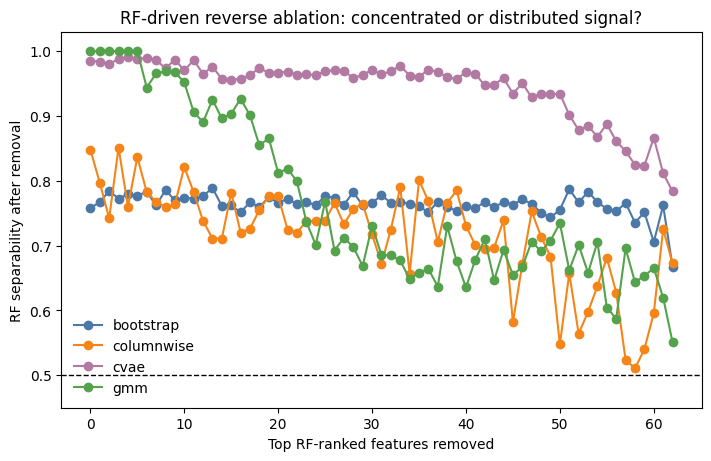

,method,feature,importance,block
0,bootstrap,V9_ACE2,0.031209,neutralization_ACE2
1,bootstrap,V8a_blood_IgGspike,0.027736,serum_IgG
2,bootstrap,V8_Saliva_IgARBD,0.027076,saliva_IgA
3,bootstrap,V1_blood_IgGspike,0.026063,serum_IgG
4,bootstrap,RATIO_CD4CD8,0.025559,CD4_CD8_neutrophils
5,bootstrap,RBDDecay_D1D2,0.024033,production_decay
6,bootstrap,V9_Saliva_IgGspike,0.023040,saliva_IgG
7,bootstrap,IFNG_production,0.021176,cytokines
8,bootstrap,V4_Saliva_IgGspike,0.020987,saliva_IgG
9,bootstrap,V5_Saliva_IgAspike,0.020571,saliva_IgA


In [10]:
fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
for method, sub in ablation_df.groupby('method'):
    sub = sub.sort_values('dropped_top_k')
    ax.plot(sub['dropped_top_k'], sub['rf_sep_mean'], marker='o', label=method, color=METHOD_COLORS.get(method, None))
ax.axhline(0.5, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Top RF-ranked features removed')
ax.set_ylabel('RF separability after removal')
ax.set_title('RF-driven reverse ablation: concentrated or distributed signal?')
ax.set_ylim(0.45, 1.03)
ax.legend(frameon=False)
plt.show()

# Top features table, useful for deciding which biological block deserves prose.
top_features = []
for method, imp in importance_by_method.items():
    tmp = imp.head(15).reset_index()
    tmp.columns = ['feature', 'importance']
    tmp.insert(0, 'method', method)
    tmp['block'] = tmp['feature'].map(primary_block)
    top_features.append(tmp)
top_features = pd.concat(top_features, ignore_index=True)
display(top_features)


## 7. Clinical metadata is an audit, not the main result

The patient workbook can strengthen the story only if used carefully. The safe unit is the participant-start row, keyed by participant index. The raw workbook is longitudinal/visit-level and would duplicate each participant-level immune profile if joined directly.

In [11]:
patient_path = DS_ROOT / 'data' / 'patient.xlsx'
feature_csv_path = DS_ROOT / 'data' / 'features_withMissForestImputation_IR_INR_together_jul25_63Features.csv'

clinical_audit = []
try:
    feature_csv = pd.read_csv(feature_csv_path)
    patient_raw = pd.read_excel(patient_path)
    patient_participant = patient_raw[patient_raw['#'].notna()].copy()
    patient_participant['participant_index'] = patient_participant['#'].astype(int)
    feature_keys = feature_csv['Unnamed: 0'].astype(int)
    patient_keys = patient_participant['participant_index'].astype(int)
    clinical_audit.append({
        'feature_rows': len(feature_csv),
        'patient_raw_rows': len(patient_raw),
        'patient_participant_rows': len(patient_participant),
        'feature_unique_keys': feature_keys.nunique(),
        'patient_unique_keys': patient_keys.nunique(),
        'keys_equal_as_sets': set(feature_keys) == set(patient_keys),
        'keys_equal_in_order': feature_keys.reset_index(drop=True).equals(patient_keys.reset_index(drop=True)),
        'participant_id_unique': patient_participant['Participant ID'].nunique() if 'Participant ID' in patient_participant else np.nan,
        'participant_id_missing': int(patient_participant['Participant ID'].isna().sum()) if 'Participant ID' in patient_participant else np.nan,
    })
    audit_df = pd.DataFrame(clinical_audit)
    display(audit_df)

    subgroup_cols = [c for c in patient_participant.columns if c.lower() in {'group', 'hiv', 'hivstatus', 'subgroup'} or 'group' in c.lower() or 'status' in c.lower()]
    print('Candidate clinical subgroup/status columns:', subgroup_cols[:10])
    if subgroup_cols:
        display(patient_participant[subgroup_cols[:5]].head())
except Exception as exc:
    display(Markdown(f'Clinical audit skipped: `{type(exc).__name__}: {exc}`'))


,feature_rows,patient_raw_rows,patient_participant_rows,feature_unique_keys,patient_unique_keys,keys_equal_as_sets,keys_equal_in_order,participant_id_unique,participant_id_missing
0,91,1311,91,91,91,True,True,NaN,NaN


Candidate clinical subgroup/status columns: ['HIV status: HIV Neg = 0, IR=1, INR=2, LLV=3, LTNP=4']


,"HIV status: HIV Neg = 0, IR=1, INR=2, LLV=3, LTNP=4"
1,0.0
15,0.0
29,0.0
43,0.0
57,0.0


## 8. Paper interpretation guardrails

**What the current results can support**

- Synthetic immune profiles from different generators leave different real-vs-synthetic signatures.
- RF separability, marginal KLD, correlation preservation, noise sensitivity, and ablation answer different questions.
- The most immunology-specific contribution is localizing distinguishability to biological feature blocks and named longitudinal immune features.
- Production/decay features can be analyzed as provided dynamic summaries, but not called mechanistic rate constants unless their formulas are recovered.
- Patient metadata can be used for clinical-context evaluation only after the participant-level join audit; raw visit rows should not be merged directly.

**What this notebook should not claim**

- It does not build a mechanistic or multiscale immune model.
- It does not prove that generated profiles preserve vaccine-response trajectories.
- It does not establish reliable subgroup preservation for LLV or LTNP, because those groups are too small.
- It does not justify conditioning on clinical immune outcomes that duplicate the feature matrix.
